In [10]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.preprocessing import LabelBinarizer

import timm
import torch
from torch import nn
from torch.nn import functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset,DataLoader, random_split
from torchvision.transforms.v2 import ToTensor, Compose, ToDtype, Resize
from torchvision.utils import save_image
from timm.models import create_model
from torchkeras import KerasModel

```python
data_dir = "../data/wf-less"
all_data = []
for pkl_file in Path(data_dir).glob('*.pkl'):
    data = pd.read_pickle(pkl_file, compression="zip")
    data.epoch = data.epoch+1
    
    all_data.append(data)
data = pd.concat(all_data, axis=0)
```

In [ ]:
img = pd.read_pickle('../data/wf-less/11.pkl', compression='zip')

In [4]:
timm.list_models('vit*')

['vit_7b_patch16_dinov3',
 'vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_dinov3',
 'vit_base_patch16_dinov3_qkvb',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_224',
 'vit_base_patch16_rope_ape_224',
 'vit_base_patch16_rope_mixed_224',
 'vit_base_patch16_rope_mixed_ape_224',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip

In [ ]:
class AOShapingDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
        
        best_iter = data.iloc[data.pib.argmax()]
        self.target_v = best_iter._v
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data.iloc[idx]
        img = sample._img[..., np.newaxis]
        v = sample._v - self.target_v
        v = v / 500
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(v, dtype=torch.float32)
    
transforms = Compose([
    ToTensor(),
    ToDtype(torch.float32, scale=True),
    Resize((80,80))
])

dataset = AOShapingDataset(img, transform=transforms)
train_dataset, test_dataset = random_split(dataset, [0.8,0.2])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 选取主干网

In [4]:
def train(model_name):
    assert model_name in timm.list_models()
    
    torch.cuda.empty_cache()
    net = create_model(model_name, in_chans=1, num_classes=64, pretrained=False)

    optimizer = Adam(net.parameters(), lr=1e-3)
    model = KerasModel(net, optimizer=optimizer, loss_fn=torch.nn.MSELoss())
    model.fit(train_loader, test_loader, epochs=20, patience=5, callbacks=[
        CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6),
    ])
    return model

<<<<<< ⚡️ cuda is used >>>>>>


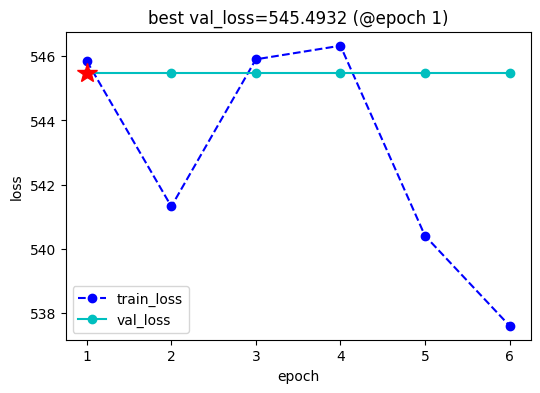

<<<<<< val_loss without improvement in 5 epoch,early stopping >>>>>> 



In [5]:
model = train('mobilenetv5_base')

<<<<<< ⚡️ cuda is used >>>>>>


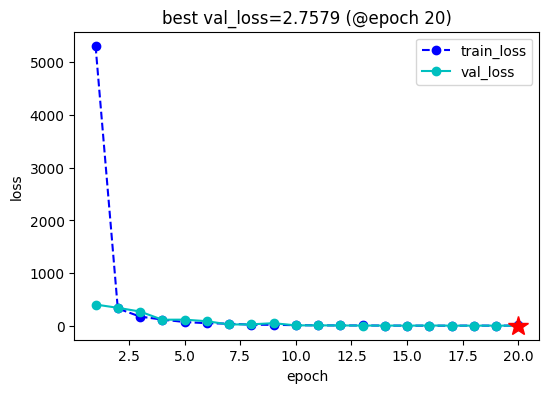

CPU times: user 5h 25min 28s, sys: 10.7 s, total: 5h 25min 38s
Wall time: 9min 56s


In [25]:
%%time
model = train('vgg13')

<<<<<< ⚡️ cuda is used >>>>>>


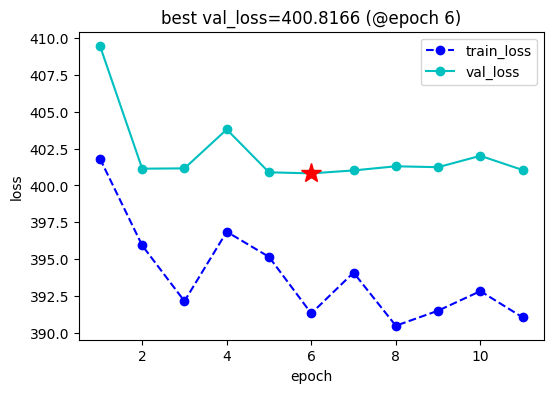

<<<<<< val_loss without improvement in 5 epoch,early stopping >>>>>> 

CPU times: user 3h 3min 16s, sys: 2.02 s, total: 3h 3min 18s
Wall time: 5min 3s


In [26]:
%%time
model = train('mambaout_kobe')

<<<<<< ⚡️ cuda is used >>>>>>


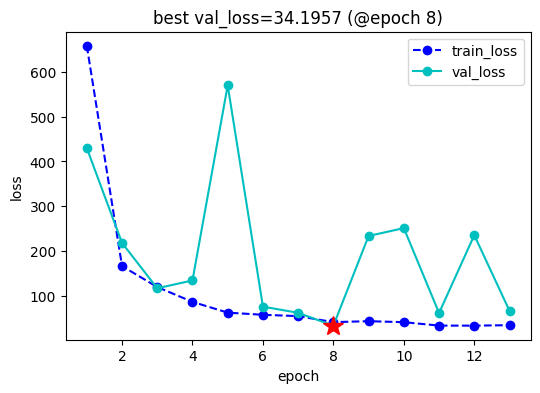

<<<<<< val_loss without improvement in 5 epoch,early stopping >>>>>> 



,epoch,train_loss,lr,val_loss
0,1,657.818926,0.001,429.928984
1,2,167.043639,0.001,218.651649
2,3,120.375120,0.001,117.597897
3,4,87.317789,0.001,135.077751
4,5,63.324937,0.001,569.542111
5,6,58.571230,0.001,76.758077
6,7,55.596198,0.001,62.915377
7,8,42.192498,0.001,34.195656
8,9,44.286903,0.001,234.123539
9,10,42.094492,0.001,251.601115


In [ ]:
%%time
model = train('inception_v4')

In [ ]:
def visualize_conv_kernels(model, layer_name="features"):
    """
    可视化VGG模型的卷积核
    
    Args:
        model: 训练好的VGG模型
        layer_name: 包含卷积层的模块名称，默认为"features"
    """
    conv_layers = []
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            conv_layers.append((name, module))
    
    if not conv_layers:
        print("No convolutional layers found in the model.")
        return
    
    # 计算总的子图数量
    total_subplots = sum(min(layer.weight.shape[0], 8) * min(layer.weight.shape[1], 8) 
                         for _, layer in conv_layers)
    
    # 创建足够大的图形
    fig, axes = plt.subplots(nrows=len(conv_layers), ncols=8, figsize=(20, 2*len(conv_layers)))
    if len(conv_layers) == 1:
        axes = [axes]
    
    for i, (name, layer) in enumerate(conv_layers):
        weights = layer.weight.data.cpu().numpy()
        
        # 显示前8个卷积核（如果有的话）
        for j in range(min(weights.shape[0], 8)):
            ax = axes[i][j] if len(conv_layers) > 1 else axes[j]
            # 显示第一个输入通道的权重
            kernel = weights[j, 0, :, :] if weights.shape[1] > 0 else weights[j, 0, :, :]
            im = ax.imshow(kernel, cmap='viridis')
            ax.set_title(f'{name}\nKernel {j}')
            ax.axis('off')
            
    plt.tight_layout()
    plt.savefig("conv_kernels.png")
    plt.show()

def visualize_feature_maps(model, input_tensor, layer_names=["features.0", "features.2", "features.5", "features.7"]):
    """
    可视化输入数据经过VGG模型各层后的特征图
    
    Args:
        model: 训练好的VGG模型
        input_tensor: 输入数据张量
        layer_names: 要可视化的层名称列表
    """
    activations = {}
    
    def hook_fn(module, input, output, name):
        activations[name] = input[0].detach().cpu().numpy()
    
    hooks = []
    for name, module in model.named_modules():
        if name in layer_names:
            hook = module.register_forward_hook(lambda module, input, output, n=name: hook_fn(module, input, output, n))
            hooks.append(hook)
    
    # 前向传播
    with torch.no_grad():
        _ = model(input_tensor.unsqueeze(0))
    
    # 移除钩子
    for hook in hooks:
        hook.remove()
    
    # 可视化特征图
    for layer_name in layer_names:
        if layer_name in activations:
            activation = activations[layer_name]
            num_features = min(activation.shape[1], 8)  # 最多显示8个特征图
            
            if num_features <= 0:
                continue
                
            fig, axes = plt.subplots(nrows=1, ncols=num_features, figsize=(15, 3))
            if num_features == 1:
                axes = [axes]
            for i in range(num_features):
                ax = axes[i]
                feature_map = activation[0, i, :, :]
                im = ax.imshow(feature_map, cmap='viridis')
                ax.set_title(f'{layer_name}\nFeature Map {i}')
                ax.axis('off')
                
            plt.suptitle(f"Feature Maps for Layer: {layer_name}")
            plt.tight_layout()
            plt.savefig(f"feature_maps_{layer_name.replace('.', '_')}.png")
            plt.show()

# 可视化VGG卷积核
visualize_conv_kernels(net)

sample1_cam = img.iloc[0].img

# 处理数据以匹配模型输入要求
def prepare_image(img):
    img = img[..., np.newaxis]  # 转换为(H, W, C)
    img_tensor = transforms(img)  # 应用变换
    return img_tensor

sample1_tensor = prepare_image(sample1_cam)
print("Visualizing feature maps for data1.iloc[0].cam")
visualize_feature_maps(net, sample1_tensor)


# DM仿真代理
 1. vae
 2. vqgan

In [33]:
class CVAE(nn.Module):
    def __init__(self):
        super(CVAE, self).__init__()
        
        self.fc1 = nn.Linear(80*80+64, 400)
        self.fc21 = nn.Linear(400, 20)
        self.fc22 = nn.Linear(400, 20)
        self.fc3 = nn.Linear(20+64, 400)
        self.fc4 = nn.Linear(400, 80*80+64)
        
    def encode(self, x, y):
        #输入样本和标签y的one-hot向量连接
        con = torch.cat((x, y), 1)
        h1 = F.relu(self.fc1(con))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        #训练时使用重参数化技巧，测试时不用。（测试时应该可以用）
        if self.training:
            std = torch.exp(0.5*logvar)
            eps = torch.randn_like(std)
            return eps.mul(std).add_(mu)
        else:
            return mu

    def decode(self, z, y):
        #解码器的输入：将z和y的one-hot向量连接
        cat = torch.cat((z, y), 1)
        h3 = F.relu(self.fc3(cat))
        return F.sigmoid(self.fc4(h3))

    def forward(self, x, y):
        mu, logvar = self.encode(x.view(-1, 80*80), y)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar

# Reconstruction + KL divergence losses summed over all elements and batch
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, size_average=False)

    # see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    # https://arxiv.org/abs/1312.6114
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

model = CVAE()
optimizer = Adam(model.parameters(), lr=1e-3)

In [34]:
def train(epoch, device='cuda:0'):
    #Sets the module in training mode.
    model.to(device)
    model.train()
    train_loss = 0

    for batch_idx, (img, voltages) in enumerate(train_loader):
        img = img.to(device)
        voltages = voltages.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(img, voltages)
        #训练样本展平，在每个样本后面连接标签的one-hot向量
        flat_data = img.view(-1, img.shape[2]*img.shape[3])
        con = torch.cat((flat_data, voltages), 1)
        
        loss = loss_function(recon_batch, con, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

        if batch_idx % 10 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch,
                batch_idx * len(img),
                len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item() / len(img)))

    print('====> Epoch: {} Average loss: {:.4f}'.format(
          epoch, train_loss / len(train_loader.dataset)))
    

EPOCH = 10
for epoch in range(1, EPOCH + 1):
    train(epoch)

/pytorch/aten/src/ATen/native/cuda/Loss.cu:91: operator(): block: [18,0,0], thread: [99,0,0] Assertion `target_val >= zero && target_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:91: operator(): block: [18,0,0], thread: [101,0,0] Assertion `target_val >= zero && target_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:91: operator(): block: [18,0,0], thread: [102,0,0] Assertion `target_val >= zero && target_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:91: operator(): block: [18,0,0], thread: [103,0,0] Assertion `target_val >= zero && target_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:91: operator(): block: [18,0,0], thread: [105,0,0] Assertion `target_val >= zero && target_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:91: operator(): block: [18,0,0], thread: [106,0,0] Assertion `target_val >= zero && target_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:91: operator(): block: [195,0,0], 

AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
BATCH_SIZE = 64
def test(epoch, device='cuda:0'):
    #Sets the module in evaluation mode
    model.eval()
    test_loss = 0

    with torch.no_grad():
        for i, (data, label) in enumerate(test_loader):
            data = data.to(device)
            recon_batch, mu, logvar = model(data, label)
            
            flat_data = data.view(-1, data.shape[2]*data.shape[3])
            
            y_condition = model.to_categrical(label)
            con = torch.cat((flat_data, y_condition), 1)
            test_loss += loss_function(recon_batch, con, mu, logvar).item()

            if i == 0:
                n = min(data.size(0), 8)
                recon_image = recon_batch[:, 0:recon_batch.shape[1]-10]
                print(recon_image.shape)
                recon_image = recon_image.view(BATCH_SIZE, 1, 28,28)
                print('---',recon_image.shape)
                comparison = torch.cat([data[:n],
                                      recon_image.view(BATCH_SIZE, 1, 28, 28)[:n]])
                save_image(comparison.cpu(),
                         'results/reconstruction_' + str(epoch) + '.png', nrow=n)

    test_loss /= len(test_loader.dataset)
    print('====> Test set loss: {:.4f}'.format(test_loss))

In [ ]:

EPOCH = 10
for epoch in range(1, EPOCH + 1):
    train(epoch)
    # test(epoch)
    # with torch.no_grad():
    #     #采样过程
    #     sample = torch.randn(64, 20).to('cuda')
      
    #     c = np.zeros(shape=(sample.shape[0],))
    #     rand = np.random.randint(0, 10)
    #     print(f"Random number: {rand}")
    #     c[:] = rand
    #     c = torch.FloatTensor(c)
    #     sample = model.decode(sample, c).cpu()
    #     #模型的输出矩阵：每一行的末尾都加了one-hot向量，要去掉这个one-hot向量再转换为图片。
    #     generated_image = sample[:, 0:sample.shape[1]-10]
        
        
    #     save_image(generated_image.view(64, 1, 28, 28),
    #                'results/sample_' + str(epoch) + '.png')

RuntimeError: shape '[-1, 784]' is invalid for input of size 204800